# CdpStC MA2020 GoC + Cav3p1: NEURON vs BrainCell Cell.run

这个 notebook 在 GoC 的 `CdpStC_MA20_GoC.mod` 基础上插入 `Cav3p1_MA20_GoC.mod`，检测 T-type Ca channel 产生的 `ica` 是否能和 CDP/STC calcium-pool ion dynamics 一起工作。


In [1]:
import os
import sys
from pathlib import Path

repo_root = Path('/home/swl/braincell-ion_dyn').resolve()
if str(repo_root) in sys.path:
    sys.path.remove(str(repo_root))
sys.path.insert(0, str(repo_root))

os.environ.setdefault('JAX_PLATFORMS', 'cpu')

import brainstate
import brainunit as u
import matplotlib.pyplot as plt
import numpy as np

import braincell
from braincell import Branch, Cell, Morphology
from braincell.filter import BranchSlice, at
from braincell.mech import Channel, CurrentClamp, CurrentProbe, Ion, MechanismProbe, StateProbe

print('braincell version:', braincell.__version__)
print('braincell import path:', Path(braincell.__file__).resolve())

brainstate.environ.set(precision=64)


braincell version: 0.1.0
braincell import path: /home/swl/braincell-ion_dyn/braincell/__init__.py


In [2]:
repo_root = Path(braincell.__file__).resolve().parent.parent
mod_dir = repo_root / 'examples' / 'neuron_compare' / 'Cerebellum_mod' / 'GoC'
ion_mod = mod_dir / 'ion' / 'CdpStC_MA20_GoC.mod'
channel_mod = mod_dir / 'channel' / 'Cav3p1_MA20_GoC.mod'
print('repo_root:', repo_root)
print('mod_dir:', mod_dir)
print('ion mod exists:', ion_mod.exists())
print('channel mod exists:', channel_mod.exists())

ion_text = ion_mod.read_text()
channel_text = channel_mod.read_text()
print('\nCdpStC INITIAL block preview:')
print(ion_text.split('INITIAL {', 1)[1].split('}', 1)[0][:1600])
print('\nCav3p1 BREAKPOINT block preview:')
print(channel_text.split('BREAKPOINT {', 1)[1].split('}', 1)[0][:900])


repo_root: /home/swl/braincell-ion_dyn
mod_dir: /home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/GoC
ion mod exists: True
channel mod exists: True

CdpStC INITIAL block preview:

		factors()

		ca = cainull
		mg = mginull
		
		Buff1 = ssBuff1()
		Buff1_ca = ssBuff1ca()

		Buff2 = ssBuff2()
		Buff2_ca = ssBuff2ca()

		BTC = ssBTC()
		BTC_ca = ssBTCca()		

		DMNPE = ssDMNPE()
		DMNPE_ca = ssDMNPEca()

		:CB = ssCB( kdf(), kds())   
	        :CB_f_ca = ssCBfast( kdf(), kds())
       	 	:CB_ca_s = ssCBslow( kdf(), kds())
        	:CB_ca_ca = ssCBca( kdf(), kds())

        	PV = ssPV( kdc(), kdm())
        	PV_ca = ssPVca(kdc(), kdm())
        	PV_mg = ssPVmg(kdc(), kdm())

	:Calmodulin
	CAM0	= CAM_start		
	CAM1C	= 0
	CAM2C	= 0
	CAM1N2C = 0
	CAM1N   = 0
	CAM2N	= 0
	CAM2N1C = 0
	CAM1C1N = 0
	CAM4	= 0
		
  	parea = PI*diam
	parea2 = PI*(diam-0.2)
	ica = 0
	ica_pmp = 0
:	ica_pmp_last = 0
	pump = TotalPump
	pumpca = 0
	
	cai = ca


Cav3p1 BREAKPOINT block preview:

	SOLVE cast

In [3]:
dt_ms = 0.05
duration_ms = 40.0
steps = int(duration_ms / dt_ms)
times_ms = np.arange(steps + 1) * dt_ms

temperature_celsius = 25.0
v_init_mV = -60.0
diam_um = 20.0
length_um = 20.0

# Keep the clamp weak. This minimal cell has no leak/Na/K balance, so a large
# current injection drives voltage unrealistically high and can destabilize the
# coupled ion/channel comparison.
stim_delay_ms = 5.0
stim_dur_ms = 20.0
stim_amp_nA = 0.005

pcabar_cm_s = 0.00025

cam_fields = [
    'CAM0',
    'CAM1C',
    'CAM2C',
    'CAM1N2C',
    'CAM1N',
    'CAM2N',
    'CAM2N1C',
    'CAM1C1N',
    'CAM4',
]

tracked_fields = ['v', 'Ci', 'ica', 'p', 'q', 'pump', 'pumpca'] + cam_fields
print({
    'dt_ms': dt_ms,
    'duration_ms': duration_ms,
    'temperature_celsius': temperature_celsius,
    'v_init_mV': v_init_mV,
    'length_um': length_um,
    'diam_um': diam_um,
    'stim_delay_ms': stim_delay_ms,
    'stim_dur_ms': stim_dur_ms,
    'stim_amp_nA': stim_amp_nA,
    'pcabar_cm_s': pcabar_cm_s,
    'tracked_fields': tracked_fields,
})


{'dt_ms': 0.05, 'duration_ms': 40.0, 'temperature_celsius': 25.0, 'v_init_mV': -60.0, 'length_um': 20.0, 'diam_um': 20.0, 'stim_delay_ms': 5.0, 'stim_dur_ms': 20.0, 'stim_amp_nA': 0.005, 'pcabar_cm_s': 0.00025, 'tracked_fields': ['v', 'Ci', 'ica', 'p', 'q', 'pump', 'pumpca', 'CAM0', 'CAM1C', 'CAM2C', 'CAM1N2C', 'CAM1N', 'CAM2N', 'CAM2N1C', 'CAM1C1N', 'CAM4']}


In [4]:
from neuron import h, load_mechanisms

compile_hint = (
    'Compile the GoC ion+channel mechanisms from examples/neuron_compare/Cerebellum_mod/GoC with:\n'
    'CPP=/usr/bin/cpp CC=/usr/bin/cc CXX=/usr/bin/c++ '
    'nrnivmodl ion/CdpStC_MA20_GoC.mod channel/Cav3p1_MA20_GoC.mod\n'
    'If this Python/Jupyter process already loaded an older GoC libnrnmech.so, restart the kernel first.'
)
if not load_mechanisms(str(mod_dir.resolve())):
    raise RuntimeError(f'NEURON mechanisms not found under {mod_dir!s}. {compile_hint}')
h.load_file('stdrun.hoc')

sec = h.Section(name='soma')
sec.L = length_um
sec.diam = diam_um
sec.nseg = 1
seg = sec(0.5)
try:
    sec.insert('CdpStC_MA20_GoC')
    sec.insert('Cav3p1_MA20_GoC')
except ValueError as exc:
    raise RuntimeError(compile_hint) from exc

ion_mech = seg.CdpStC_MA20_GoC
channel_mech = seg.Cav3p1_MA20_GoC
channel_mech.pcabar = pcabar_cm_s

stim = h.IClamp(seg)
stim.delay = stim_delay_ms
stim.dur = stim_dur_ms
stim.amp = stim_amp_nA

h.celsius = temperature_celsius
h.dt = dt_ms
h.steps_per_ms = 1.0 / h.dt
h.tstop = duration_ms
h.v_init = v_init_mV

t_vec = h.Vector().record(h._ref_t)
v_vec = h.Vector().record(seg._ref_v)
cai_vec = h.Vector().record(seg._ref_cai)
ica_vec = h.Vector().record(seg._ref_ica)
pump_vec = h.Vector().record(ion_mech._ref_pump)
pumpca_vec = h.Vector().record(ion_mech._ref_pumpca)
m_vec = h.Vector().record(channel_mech._ref_m)
h_gate_vec = h.Vector().record(channel_mech._ref_h)
cam_vectors = {name: h.Vector().record(getattr(ion_mech, f'_ref_{name}')) for name in cam_fields}

h.finitialize(h.v_init)
h.frecord_init()
h.continuerun(h.tstop)

neuron_t_ms = np.asarray(t_vec)
neuron_data = {
    'v': np.asarray(v_vec),
    'Ci': np.asarray(cai_vec),
    # BrainCell channels report inward Ca current as positive g*(E - V),
    # while this NMODL writes ica = g*(v - eca).
    'ica': -np.asarray(ica_vec),
    'pump': np.asarray(pump_vec),
    'pumpca': np.asarray(pumpca_vec),
    'p': np.asarray(m_vec),
    'q': np.asarray(h_gate_vec),
}
for name, vec in cam_vectors.items():
    neuron_data[name] = np.asarray(vec)
neuron_total = neuron_data['pump'] + neuron_data['pumpca']

print('max |-NEURON ica|:', float(np.max(np.abs(neuron_data['ica']))))
print('NEURON start/end v:', float(neuron_data['v'][0]), float(neuron_data['v'][-1]))
print('NEURON start/end cai:', float(neuron_data['Ci'][0]), float(neuron_data['Ci'][-1]))
print('NEURON start/end Cav3p1 p/q (from m/h):', float(neuron_data['p'][0]), float(neuron_data['p'][-1]), float(neuron_data['q'][0]), float(neuron_data['q'][-1]))
print('NEURON start/end pump:', float(neuron_data['pump'][0]), float(neuron_data['pump'][-1]))
print('NEURON start/end pumpca:', float(neuron_data['pumpca'][0]), float(neuron_data['pumpca'][-1]))
print('NEURON max pump conserve drift:', float(np.max(np.abs(neuron_total - neuron_total[0]))))
for name in cam_fields:
    arr = neuron_data[name]
    print(f'NEURON {name} start/end:', float(arr[0]), float(arr[-1]))


max |-NEURON ica|: 0.009307425228708612
NEURON start/end v: -60.0 55.786257723892014
NEURON start/end cai: 4.5e-05 5.171951874237618e-05
NEURON start/end Cav3p1 p/q (from m/h): 0.16798161486607552 0.9998743095352342 0.15260866484263105 0.08201692803440491
NEURON start/end pump: 1e-09 9.999907611676755e-10
NEURON start/end pumpca: 0.0 9.238832324461509e-15
NEURON max pump conserve drift: 2.0679515313825692e-25
NEURON CAM0 start/end: 0.03 0.029684016498184758
NEURON CAM1C start/end: 0.0 0.0002083099589193997
NEURON CAM2C start/end: 0.0 1.8426337575906664e-05
NEURON CAM1N2C start/end: 0.0 5.432436172318496e-08
NEURON CAM1N start/end: 0.0 8.751414494744486e-05
NEURON CAM2N start/end: 0.0 1.056528380256236e-06
NEURON CAM2N1C start/end: 0.0 7.414273174484753e-09
NEURON CAM1C1N start/end: 0.0 6.141375177182283e-07
NEURON CAM4 start/end: 0.0 6.558396556031956e-10


--No graphics will be displayed.


In [5]:
dt = dt_ms * u.ms
duration = duration_ms * u.ms

soma = Branch.from_lengths(lengths=[length_um] * u.um, radii=[diam_um / 2.0, diam_um / 2.0] * u.um, type='soma')
morpho = Morphology.from_root(soma, name='soma')
region = BranchSlice(branch_index=0, prox=0.0, dist=1.0)

cell = Cell(morpho, solver='staggered', V_init=v_init_mV * u.mV)
cell.paint(
    region,
    Ion(
        'CdpStC_MA2020_GoC',
        name='ca_stc',
        temp=u.celsius2kelvin(temperature_celsius),
    ),
)
cell.paint(
    region,
    Channel(
        'Cav3p1_MA2020_GoC',
        ion_name='ca_stc',
        g_max=pcabar_cm_s * (u.cm / u.second),
        temp=u.celsius2kelvin(temperature_celsius),
    ),
)
cell.place(
    at('soma', 0.5),
    CurrentClamp(delay=stim_delay_ms * u.ms, durations=stim_dur_ms * u.ms, amplitudes=stim_amp_nA * u.nA),
    StateProbe(),
    MechanismProbe(mechanism='ca_stc', field='Ci'),
    MechanismProbe(mechanism='ca_stc', field='pump'),
    MechanismProbe(mechanism='ca_stc', field='pumpca'),
    MechanismProbe(mechanism='ca_stc', field='CAM0'),
    MechanismProbe(mechanism='ca_stc', field='CAM1C'),
    MechanismProbe(mechanism='ca_stc', field='CAM2C'),
    MechanismProbe(mechanism='ca_stc', field='CAM1N2C'),
    MechanismProbe(mechanism='ca_stc', field='CAM1N'),
    MechanismProbe(mechanism='ca_stc', field='CAM2N'),
    MechanismProbe(mechanism='ca_stc', field='CAM2N1C'),
    MechanismProbe(mechanism='ca_stc', field='CAM1C1N'),
    MechanismProbe(mechanism='ca_stc', field='CAM4'),
    MechanismProbe(mechanism='ca_stc', field='vrat'),
    MechanismProbe(mechanism='ca_stc', field='parea'),
    MechanismProbe(mechanism='ca_stc', field='dsq'),
    MechanismProbe(mechanism='ca_stc', field='dsqvol'),
    MechanismProbe(mechanism='Cav3p1_MA2020_GoC', field='p'),
    MechanismProbe(mechanism='Cav3p1_MA2020_GoC', field='q'),
    CurrentProbe(ion='ca_stc', mechanism='Cav3p1_MA2020_GoC'),
)

with brainstate.environ.context(precision=64):
    cell.init_state()
    # HH channel reset_state sets gates to the NEURON INITIAL steady state.
    cell.reset_state()
    print('initial probe v (mV):', float(np.asarray(cell.sample_probe('soma(0.5)_v').to_decimal(u.mV)).reshape(-1)[0]))
    print('initial probe Ci (mM):', float(np.asarray(cell.sample_probe('soma(0.5)_ca_stc_Ci').to_decimal(u.mM)).reshape(-1)[0]))
    print('initial probe Cav3p1 p/q:', float(np.asarray(cell.sample_probe('soma(0.5)_Cav3p1_MA2020_GoC_p')).reshape(-1)[0]), float(np.asarray(cell.sample_probe('soma(0.5)_Cav3p1_MA2020_GoC_q')).reshape(-1)[0]))
    run_result = cell.run(dt=dt, duration=duration)

cell_data = {
    'v': np.asarray(run_result.traces['soma(0.5)_v'].to_decimal(u.mV)),
    'Ci': np.asarray(run_result.traces['soma(0.5)_ca_stc_Ci'].to_decimal(u.mM)),
    'pump': np.asarray(run_result.traces['soma(0.5)_ca_stc_pump'].to_decimal(u.mol / u.cm ** 2)),
    'pumpca': np.asarray(run_result.traces['soma(0.5)_ca_stc_pumpca'].to_decimal(u.mol / u.cm ** 2)),
    'p': np.asarray(run_result.traces['soma(0.5)_Cav3p1_MA2020_GoC_p']),
    'q': np.asarray(run_result.traces['soma(0.5)_Cav3p1_MA2020_GoC_q']),
    'ica': np.asarray(run_result.traces['soma(0.5)_Cav3p1_MA2020_GoC_current'].to_decimal(u.mA / (u.cm ** 2))),
}
for name in cam_fields:
    cell_data[name] = np.asarray(run_result.traces[f'soma(0.5)_ca_stc_{name}'].to_decimal(u.mM))
cell_geometry = {
    'vrat': np.asarray(run_result.traces['soma(0.5)_ca_stc_vrat']),
    'parea': np.asarray(run_result.traces['soma(0.5)_ca_stc_parea'].to_decimal(u.um)),
    'dsq': np.asarray(run_result.traces['soma(0.5)_ca_stc_dsq'].to_decimal(u.um ** 2)),
    'dsqvol': np.asarray(run_result.traces['soma(0.5)_ca_stc_dsqvol'].to_decimal(u.um ** 2)),
}
cell_total = cell_data['pump'] + cell_data['pumpca']

print('Cell.run max |current|:', float(np.max(np.abs(cell_data['ica']))))
print('Cell.run start/end v:', float(cell_data['v'][0]), float(cell_data['v'][-1]))
print('Cell.run start/end Ci:', float(cell_data['Ci'][0]), float(cell_data['Ci'][-1]))
print('Cell.run start/end Cav3p1 p/q:', float(cell_data['p'][0]), float(cell_data['p'][-1]), float(cell_data['q'][0]), float(cell_data['q'][-1]))
print('Cell.run start/end pump:', float(cell_data['pump'][0]), float(cell_data['pump'][-1]))
print('Cell.run start/end pumpca:', float(cell_data['pumpca'][0]), float(cell_data['pumpca'][-1]))
print('Cell.run max pump conserve drift:', float(np.max(np.abs(cell_total - cell_total[0]))))
for name in cam_fields:
    arr = cell_data[name]
    print(f'Cell.run {name} start/end:', float(arr[0]), float(arr[-1]))
for name, arr in cell_geometry.items():
    print(f'Cell.run {name} first/last:', float(arr[0]), float(arr[-1]))
for name, arr in cell_data.items():
    assert np.isfinite(arr).all(), f'{name} contains non-finite values'


initial probe v (mV): -60.0
initial probe Ci (mM): 4.5e-05
initial probe Cav3p1 p/q: 0.16798161486607552 0.15260866484263105
Cell.run max |current|: 0.00932875118807175
Cell.run start/end v: -59.90220484662791 55.63249752394902
Cell.run start/end Ci: 5.021719416644264e-05 5.176965632570347e-05
Cell.run start/end Cav3p1 p/q: 0.16798788833906497 0.9998663281654286 0.15260831548697876 0.08205503563053941
Cell.run start/end pump: 9.99999992467455e-10 9.999907336792863e-10
Cell.run start/end pumpca: 7.532545021818129e-18 9.266320713735153e-15
Cell.run max pump conserve drift: 0.0
Cell.run CAM0 start/end: 0.029919915720659104 0.029683672741443807
Cell.run CAM1C start/end: 1.1750217136119726e-05 0.00020851997237721927
Cell.run CAM2C start/end: 1.2034711831970356e-08 1.8472737071501166e-05
Cell.run CAM1N2C start/end: 3.056682335527731e-11 5.4513973078824696e-08
Cell.run CAM1N start/end: 6.791099118296192e-05 8.759801727433116e-05
Cell.run CAM2N start/end: 3.8201287797093865e-07 1.0585699736546

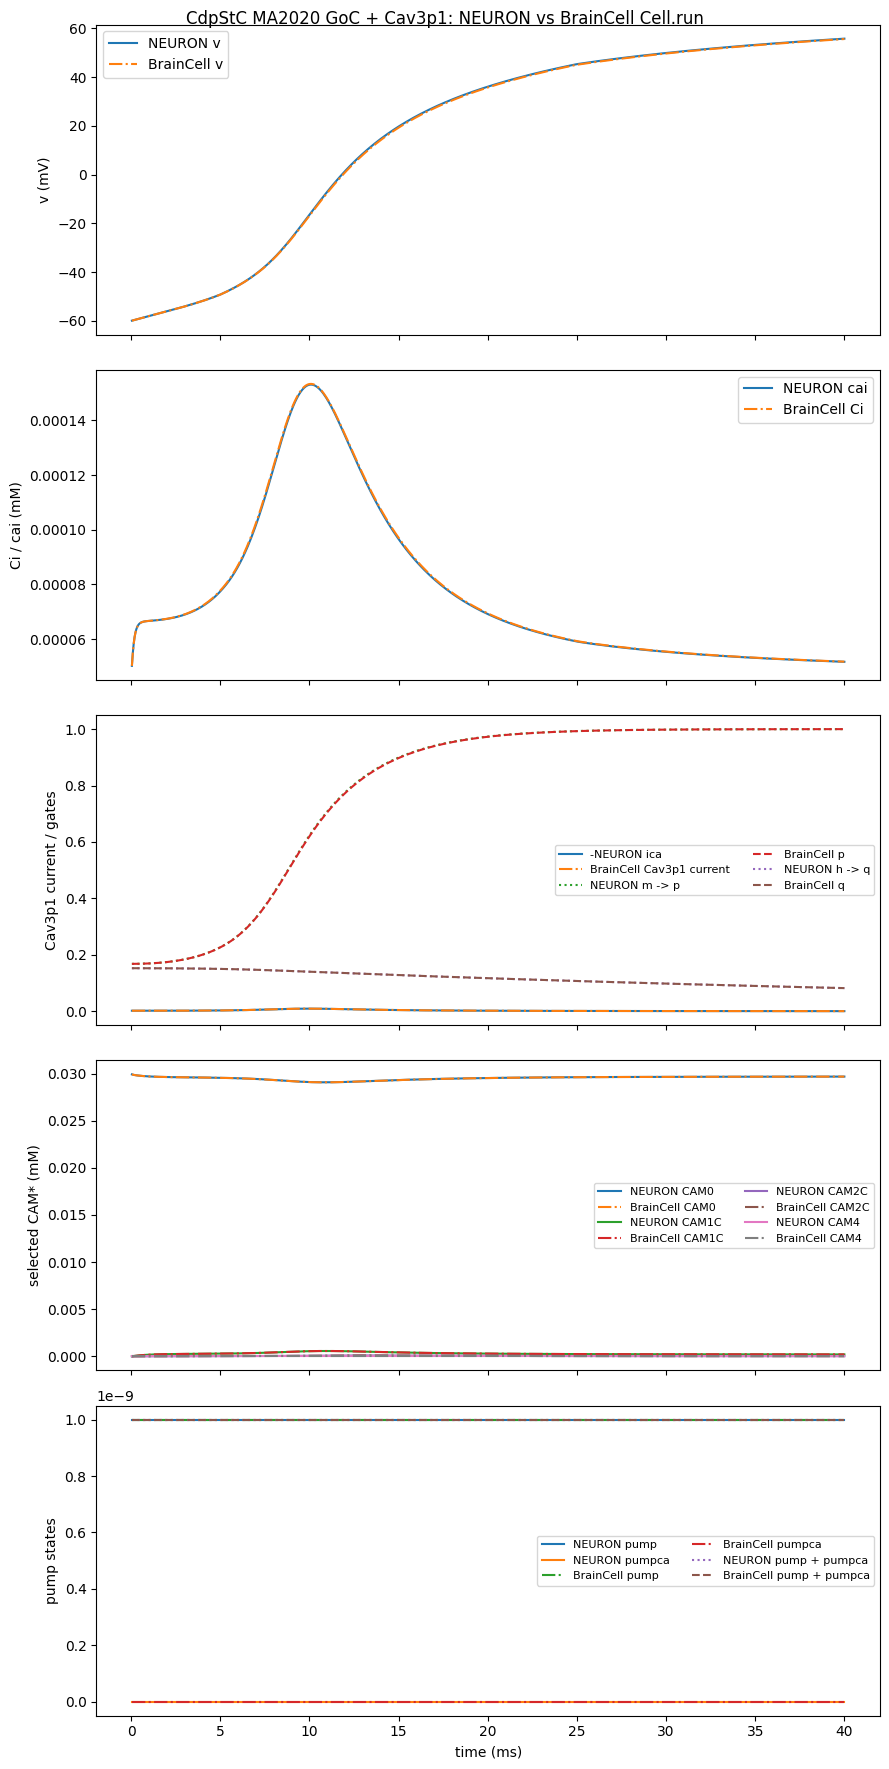

Per-field Cell.run vs NEURON error summary:
v {'mae': 0.2369274953202346, 'rmse': 0.2778377984228136, 'max_abs': 0.512748831112452}
Ci {'mae': 2.3024482568001632e-07, 'rmse': 2.986194284098945e-07, 'max_abs': 7.725434263536926e-07}
ica {'mae': 1.9216067867575977e-05, 'rmse': 2.5467670502020458e-05, 'max_abs': 6.748715225050883e-05}
p {'mae': 0.000725396702380138, 'rmse': 0.0011617979847194193, 'max_abs': 0.0029149532165680947}
q {'mae': 2.9755859567338963e-05, 'rmse': 3.229287037606174e-05, 'max_abs': 3.814026658005565e-05}
pump {'mae': 1.7193818830164863e-17, 'rmse': 1.9644510697836823e-17, 'max_abs': 2.748838924673908e-17}
pumpca {'mae': 1.719381877118146e-17, 'rmse': 1.964451064337746e-17, 'max_abs': 2.748838927364397e-17}
CAM0 {'mae': 1.5642894659466953e-06, 'rmse': 1.9704519739273094e-06, 'max_abs': 4.373838594865648e-06}
CAM1C {'mae': 8.878281751953629e-07, 'rmse': 1.118696237331422e-06, 'max_abs': 2.6111841838001755e-06}
CAM2C {'mae': 2.701343332432344e-07, 'rmse': 3.53002409365

In [6]:
compare_t_ms = neuron_t_ms[1:]

def summarize_error(y, ref):
    y = np.asarray(y)
    ref = np.asarray(ref)
    n = min(len(y), len(ref))
    diff = y[:n] - ref[:n]
    return {
        'mae': float(np.mean(np.abs(diff))),
        'rmse': float(np.sqrt(np.mean(diff ** 2))),
        'max_abs': float(np.max(np.abs(diff))),
    }

error_summary = {}
for name in tracked_fields:
    neuron_cmp = neuron_data[name][1:]
    cell_cmp = cell_data[name]
    error_summary[name] = summarize_error(cell_cmp, neuron_cmp[:len(cell_cmp)])

fig, axes = plt.subplots(5, 1, figsize=(9, 18), sharex=True)

axes[0].plot(compare_t_ms, neuron_data['v'][1:], label='NEURON v')
axes[0].plot(compare_t_ms[:len(cell_data['v'])], cell_data['v'], '-.', label='BrainCell v')
axes[0].set_ylabel('v (mV)')
axes[0].legend()

axes[1].plot(compare_t_ms, neuron_data['Ci'][1:], label='NEURON cai')
axes[1].plot(compare_t_ms[:len(cell_data['Ci'])], cell_data['Ci'], '-.', label='BrainCell Ci')
axes[1].set_ylabel('Ci / cai (mM)')
axes[1].legend()

axes[2].plot(compare_t_ms, neuron_data['ica'][1:], label='-NEURON ica')
axes[2].plot(compare_t_ms[:len(cell_data['ica'])], cell_data['ica'], '-.', label='BrainCell Cav3p1 current')
axes[2].plot(compare_t_ms, neuron_data['p'][1:], ':', label='NEURON m -> p')
axes[2].plot(compare_t_ms[:len(cell_data['p'])], cell_data['p'], '--', label='BrainCell p')
axes[2].plot(compare_t_ms, neuron_data['q'][1:], ':', label='NEURON h -> q')
axes[2].plot(compare_t_ms[:len(cell_data['q'])], cell_data['q'], '--', label='BrainCell q')
axes[2].set_ylabel('Cav3p1 current / gates')
axes[2].legend(ncol=2, fontsize=8)

for name in ['CAM0', 'CAM1C', 'CAM2C', 'CAM4']:
    axes[3].plot(compare_t_ms, neuron_data[name][1:], label=f'NEURON {name}')
    axes[3].plot(compare_t_ms[:len(cell_data[name])], cell_data[name], '-.', label=f'BrainCell {name}')
axes[3].set_ylabel('selected CAM* (mM)')
axes[3].legend(ncol=2, fontsize=8)

axes[4].plot(compare_t_ms, neuron_data['pump'][1:], label='NEURON pump')
axes[4].plot(compare_t_ms, neuron_data['pumpca'][1:], label='NEURON pumpca')
axes[4].plot(compare_t_ms[:len(cell_data['pump'])], cell_data['pump'], '-.', label='BrainCell pump')
axes[4].plot(compare_t_ms[:len(cell_data['pumpca'])], cell_data['pumpca'], '-.', label='BrainCell pumpca')
axes[4].plot(compare_t_ms, neuron_total[1:], ':', label='NEURON pump + pumpca')
axes[4].plot(compare_t_ms[:len(cell_total)], cell_total, '--', label='BrainCell pump + pumpca')
axes[4].set_xlabel('time (ms)')
axes[4].set_ylabel('pump states')
axes[4].legend(ncol=2, fontsize=8)

plt.suptitle('CdpStC MA2020 GoC + Cav3p1: NEURON vs BrainCell Cell.run')
plt.tight_layout()
plt.show()

print('Per-field Cell.run vs NEURON error summary:')
for name in tracked_fields:
    print(name, error_summary[name])

print('\nPump conserve drift:')
print('  NEURON:', float(np.max(np.abs(neuron_total - neuron_total[0]))))
print('  BrainCell Cell.run:', float(np.max(np.abs(cell_total - cell_total[0]))))

print('\nCa current nonzero check:')
print('  max |-NEURON ica|:', float(np.max(np.abs(neuron_data['ica']))))
print('  max |BrainCell current|:', float(np.max(np.abs(cell_data['ica']))))

cam_extra = ['CAM1N2C', 'CAM1N', 'CAM2N', 'CAM2N1C', 'CAM1C1N']
print('\nExtra CAM* end-state comparison:')
for name in cam_extra:
    print(
        name,
        {
            'NEURON_end': float(neuron_data[name][-1]),
            'cell_end': float(cell_data[name][-1]),
        },
    )
